# EEG_14 — DHSLP: Pretrain S-Indep + Calibrazione per Soggetto (PRE/POST-CAL)

**Schema**:
```
Pretrain: SUBJ_TRAIN (0–59) — TUTTE le sessioni e parole → modello universale M
  val interna pretrain: 10% random split dei trial di SUBJ_TRAIN (no soggetti separati)
                ↓
  Per ogni soggetto SUBJ_TEST (60–73) con ≥ 5 sessioni:

    Pipeline A — PRE-CAL:
      M → valutazione diretta su sess.5 (nessun FT)

    Pipeline B — Calibrazione:
      FT su sess.1-2-3 (train) + sess.4 (val) → valutazione su sess.5

    Δ = POST-CAL − PRE-CAL
```

**SUBJ_TRAIN (0–59)**: 60 soggetti — include l'ex-SUBJ_VAL (50–59) mergiato per massimizzare i dati di pretrain.  
**SUBJ_TEST (60–73)**: 14 soggetti completamente esclusi dal pretrain → calibrazione PRE/POST-CAL.  
**Solo soggetti con tutte le sessioni 1-5** entrano nel loop di calibrazione (`SUBJ_CAL`).

In [1]:
import json, logging, re, traceback
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score, recall_score
from tqdm.auto import tqdm
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg14')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg14'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ---- CONFIG ----
N_CHANNELS   = 61
N_SAMPLES    = 384
N_CLASSES    = 4
CLUSTER_SCHEME = 'concr4'

K_WINDOWS  = 8
N_EDGES    = 16
D_MODEL    = 64
HIDDEN     = 128
N_LAYERS   = 2
T_WIN      = N_SAMPLES // K_WINDOWS   # 48

# Split soggetti
# SUBJ_TRAIN (0-59): tutte le sessioni → pretrain M
# SUBJ_TEST  (60-72): mai visti nel pretrain → calibrazione PRE/POST-CAL
# Nessun SUBJ_VAL separato — val pretrain = 10% random dei trial di training
SUBJ_TRAIN = list(range(0, 60))   # 60 soggetti per M (ex SUBJ_VAL ora incluso)
SUBJ_TEST  = list(range(60, 74))  # 13 soggetti per calibrazione

PRETRAIN_VAL_FRAC = 0.10   # 10% dei trial train usati come val pretrain

# --- CONFIG PRETRAIN ---
PRETRAIN_DROPOUT       = 0.4
PRETRAIN_LR            = 1e-3
PRETRAIN_WEIGHT_DECAY  = 3e-3
PRETRAIN_BATCH_SIZE    = 64
PRETRAIN_MAX_EPOCHS    = 60
PRETRAIN_PATIENCE      = 12
PRETRAIN_LABEL_SMOOTH  = 0.20
PRETRAIN_MIXUP_ALPHA   = 0.4   # Mixup durante pretrain
PRETRAIN_GRAD_CLIP     = 1.0

PRETRAIN_CKPT = CKPT_DIR / 'pretrain_E16_d64.pt'

# --- CONFIG CALIBRAZIONE ---
FT_TRAIN_SESSIONS = [1, 2, 3, 4]  # sess. 0-3 (0-indexed) = tutte le sessioni tranne test
FT_TEST_SESSION   = 5

FT_DROPOUT       = 0.5
FT_LR            = 1e-4
FT_WEIGHT_DECAY  = 1e-2
FT_BATCH_SIZE    = 32
FT_MAX_EPOCHS    = 40
FT_PATIENCE      = 8
FT_LABEL_SMOOTH  = 0.20
FT_MIXUP_ALPHA   = 0.4   # Mixup augmentation durante fine-tune
FT_GRAD_CLIP     = 1.0
USE_INSTANCE_NORM = True

DATA_METRIC   = 'abs_pcc'
WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k,v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'
subj_sess = defaultdict(lambda: defaultdict(list))
for p in sorted(HG_ROOT.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m:
        subj_sess[int(m.group(1))][int(m.group(2))].append(p)

ALL_SUBJ = sorted(subj_sess.keys())

SUBJ_CAL = [s for s in SUBJ_TEST if s in subj_sess and
            all(ses in subj_sess[s] for ses in FT_TRAIN_SESSIONS + [FT_TEST_SESSION])]

log.info(f'SUBJ_TRAIN={len(SUBJ_TRAIN)} sogg. (0-59) — pretrain M (tutte le sessioni)')
log.info(f'SUBJ_TEST ={len(SUBJ_TEST)} sogg. (60-72) — mai visti nel pretrain')
log.info(f'SUBJ_CAL  ={len(SUBJ_CAL)} sogg. con ≥5 sessioni → candidati calibrazione')
log.info(f'Pretrain val: {int(PRETRAIN_VAL_FRAC*100)}% random split dai trial di training')
log.info(f'PRETRAIN: DO={PRETRAIN_DROPOUT}  WD={PRETRAIN_WEIGHT_DECAY}  LS={PRETRAIN_LABEL_SMOOTH}')
log.info(f'FT:       DO={FT_DROPOUT}  WD={FT_WEIGHT_DECAY}  LR={FT_LR}')

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
12:01:20 INFO     SUBJ_TRAIN=60 sogg. (0-59) — pretrain M (tutte le sessioni)
12:01:20 INFO     SUBJ_TEST =14 sogg. (60-72) — mai visti nel pretrain
12:01:20 INFO     SUBJ_CAL  =13 sogg. con ≥5 sessioni → candidati calibrazione
12:01:20 INFO     Pretrain val: 10% random split dai trial di training
12:01:20 INFO     PRETRAIN: DO=0.4  WD=0.003  LS=0.2
12:01:20 INFO     FT:       DO=0.5  WD=0.01  LR=0.0001


## §1 — Dataset

In [2]:
class EEGRawDatasetSS(Dataset):
    """Carica x (61,384) e y da lista di (path, label). H ignorata."""
    def __init__(self, paths_and_labels, use_instance_norm=True):
        self.items = paths_and_labels
        self.use_instance_norm = use_instance_norm

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        p, label = self.items[idx]
        d = torch.load(p, weights_only=False)
        x = d['x'].float()
        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        return x, torch.tensor(label, dtype=torch.long)


def _collect(subj_ids, sessions=None):
    items = []
    for sid in subj_ids:
        sess_keys = list(subj_sess[sid].keys()) if sessions is None else sessions
        for s in sess_keys:
            for p in subj_sess[sid].get(s, []):
                d = torch.load(p, weights_only=False)
                y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
                c = label2cluster.get(y_word)
                if c is not None:
                    items.append((p, c))
    return items


def make_weighted_loader(items, batch_size):
    labels   = np.array([it[1] for it in items])
    counts   = np.bincount(labels, minlength=N_CLASSES)
    sample_w = torch.tensor(1.0 / counts[labels], dtype=torch.float)
    sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
    return DataLoader(EEGRawDatasetSS(items, USE_INSTANCE_NORM), batch_size,
                      sampler=sampler, num_workers=0, pin_memory=False)


def make_plain_loader(items, batch_size):
    return DataLoader(EEGRawDatasetSS(items, USE_INSTANCE_NORM), batch_size,
                      shuffle=False, num_workers=0, pin_memory=False)


# ---- Pretrain loaders: SUBJ_TRAIN (0-59) tutte sessioni, val=10% random ----

def make_pretrain_loaders(val_frac=PRETRAIN_VAL_FRAC, seed=42):
    all_items = _collect(SUBJ_TRAIN, sessions=None)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(all_items))
    n_val = int(len(all_items) * val_frac)
    va_items = [all_items[i] for i in idx[:n_val]]
    tr_items = [all_items[i] for i in idx[n_val:]]
    log.info(f'Pretrain  train: {len(tr_items)} trial  ({len(SUBJ_TRAIN)} sogg., tutte sessioni)')
    log.info(f'Pretrain  val:   {len(va_items)} trial  ({val_frac*100:.0f}% random split)')
    return make_weighted_loader(tr_items, PRETRAIN_BATCH_SIZE), \
           make_plain_loader(va_items,   PRETRAIN_BATCH_SIZE)


# ---- Calibrazione loaders: soggetto test, split fisso sessioni ----

def make_cal_loaders(subj_id):
    """sess. 1-4 fine-tune | sess. 5 test  (0-indexed: sess. 0-3 train, sess. 4 test)"""
    tr_items = _collect([subj_id], FT_TRAIN_SESSIONS)
    te_items = _collect([subj_id], [FT_TEST_SESSION])
    if not tr_items or not te_items:
        return None
    return (make_weighted_loader(tr_items, FT_BATCH_SIZE),
            make_plain_loader(te_items,    FT_BATCH_SIZE))


log.info('Dataset OK')

12:01:20 INFO     Dataset OK


## §2 — Modello DHSLP

In [3]:
class HGNNConv(nn.Module):
    """HGNN spectral convolution layer (Feng et al. 2019) — batched."""
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, H):
        # X: (B,N,C)  H: (B,N,E) — soft incidence matrix dinamica
        d_v = H.sum(dim=2).clamp(min=1e-6)
        d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1)
        De  = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out


class DHSLP(nn.Module):
    """
    Dynamic Hypergraph Spectral Learning with Positional encoding.
    Ispirato a Li et al. 2025.

    Input:  x (B, 61, 384)  — nessuna H in input
    Output: logits (B, 4)

    Pipeline per finestra temporale k:
      feat_k = Linear(x_k) + pos_enc        → (B, 61, d)
      H_k    = softmax(feat_k @ E^T / √d)   → (B, 61, n_edges)  [DINAMICA]
      out_k  = HGNNConv(feat_k, H_k).mean   → (B, hidden)
    z = mean(out_1..K) → Linear → logits
    """
    def __init__(self, n_nodes=N_CHANNELS, T_win=T_WIN, K=K_WINDOWS,
                 n_edges=N_EDGES, d_model=D_MODEL, hidden=HIDDEN,
                 n_classes=N_CLASSES, n_layers=N_LAYERS, dropout=0.3):
        super().__init__()
        self.K, self.T_win, self.d_model = K, T_win, d_model

        # Learnable iperedge embeddings — E ∈ R^{n_edges × d}
        self.E = nn.Parameter(torch.randn(n_edges, d_model) * 0.01)
        # Encoding posizionale per elettrodo — pos_enc ∈ R^{61 × d}
        self.pos_enc = nn.Parameter(torch.randn(n_nodes, d_model) * 0.01)

        self.node_proj = nn.Sequential(
            nn.Linear(T_win, d_model),
            nn.LayerNorm(d_model),
            nn.ELU(),
        )
        dims = [d_model] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)

    def build_dynamic_H(self, feat):
        """feat: (B,N,d)  →  H: (B,N,n_edges) — soft assignment nodo→iperedge."""
        scores = torch.matmul(feat, self.E.T) / (self.d_model ** 0.5)
        return torch.softmax(scores, dim=2)

    def forward(self, x):
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k  = x[:, :, k*self.T_win:(k+1)*self.T_win]   # (B,N,T_win)
            feat = self.node_proj(x_k) + self.pos_enc        # (B,N,d)
            H_k  = self.build_dynamic_H(feat)                # (B,N,n_edges)
            out  = feat
            for conv, bn in zip(self.convs, self.bns):
                out = conv(out, H_k)
                out = bn(out.reshape(B*N, -1)).reshape(B, N, -1)
                out = F.relu(out)
                out = self.drop(out)
            outs.append(out.mean(dim=1))   # (B, hidden)
        return self.clf(torch.stack(outs, dim=1).mean(dim=1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'device: {device}')

# Sanity check architettura
_m = DHSLP(dropout=PRETRAIN_DROPOUT)
_x = torch.randn(4, N_CHANNELS, N_SAMPLES)
assert _m(_x).shape == (4, N_CLASSES)
n_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
log.info(f'DHSLP OK — {n_p:,} parametri  K={K_WINDOWS} N_EDGES={N_EDGES} D_MODEL={D_MODEL}')
del _m, _x

12:01:20 INFO     device: cuda
12:01:20 INFO     DHSLP OK — 34,052 parametri  K=8 N_EDGES=16 D_MODEL=64


## §3 — Pretrain S-Indep

Train su **SUBJ_TRAIN (0–59)** — tutte le sessioni. Val interna = 10% random split dei trial di training (nessun gruppo soggetti separato).  
Salva checkpoint su disco per il fine-tuning.

Se `PRETRAIN_CKPT` esiste già, questo step può essere saltato (`SKIP_PRETRAIN = True`).

In [4]:
# SKIP_PRETRAIN = True   # imposta True per riusare checkpoint su disco
SKIP_PRETRAIN = False

if SKIP_PRETRAIN:
    log.info(f'Skip pretrain — uso checkpoint: {PRETRAIN_CKPT}')
else:
    log.info('=== PRETRAIN (SUBJ_TRAIN 0-59, tutte le sessioni) ===')
    pt_tr_loader, pt_va_loader = make_pretrain_loaders()

    pretrain_model = DHSLP(dropout=PRETRAIN_DROPOUT).to(device)
    pt_criterion   = nn.CrossEntropyLoss(label_smoothing=PRETRAIN_LABEL_SMOOTH)
    pt_optimizer   = torch.optim.Adam(pretrain_model.parameters(),
                                      lr=PRETRAIN_LR, weight_decay=PRETRAIN_WEIGHT_DECAY)
    pt_sched       = torch.optim.lr_scheduler.CosineAnnealingLR(pt_optimizer, T_max=PRETRAIN_MAX_EPOCHS)

    pt_run = wandb.init(
        entity=WANDB_ENTITY, project=WANDB_PROJECT,
        name=f'eeg14_pretrain_v3_DHSLP_{CLUSTER_SCHEME}',
        config=dict(
            notebook='EEG_14', phase='pretrain_v3', model='DHSLP',
            n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
            k_windows=K_WINDOWS, n_edges=N_EDGES, d_model=D_MODEL,
            dropout=PRETRAIN_DROPOUT, lr=PRETRAIN_LR,
            weight_decay=PRETRAIN_WEIGHT_DECAY,
            label_smoothing=PRETRAIN_LABEL_SMOOTH,
            grad_clip=PRETRAIN_GRAD_CLIP,
            batch_size=PRETRAIN_BATCH_SIZE, max_epochs=PRETRAIN_MAX_EPOCHS,
            n_train_subj=len(SUBJ_TRAIN),
            pretrain_val_frac=PRETRAIN_VAL_FRAC,
            pretrain_sessions='all',
        ),
        reinit='finish_previous',
        settings=wandb.Settings(start_method='thread')
    )

    pt_best_val, pt_best_state, pt_patience = 0.0, None, 0

    def _run_epoch_pt(model, loader, optimizer=None):
        train = optimizer is not None
        model.train() if train else model.eval()
        total_loss, all_lbl, all_pred = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss   = pt_criterion(logits, y)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), PRETRAIN_GRAD_CLIP)
                    optimizer.step()
                total_loss += loss.item() * len(y)
                all_lbl.extend(y.cpu().numpy())
                all_pred.extend(logits.argmax(1).cpu().numpy())
        return total_loss / len(loader.dataset), balanced_accuracy_score(all_lbl, all_pred)

    for epoch in range(1, PRETRAIN_MAX_EPOCHS + 1):
        tr_loss, tr_b = _run_epoch_pt(pretrain_model, pt_tr_loader, pt_optimizer)
        va_loss, va_b = _run_epoch_pt(pretrain_model, pt_va_loader)
        pt_sched.step()
        pt_run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                    'val/loss': va_loss,   'val/bacc': va_b, 'epoch': epoch})
        if va_b > pt_best_val:
            pt_best_val = va_b
            pt_best_state = {k: v.cpu().clone() for k, v in pretrain_model.state_dict().items()}
            pt_patience = 0
        else:
            pt_patience += 1
        if pt_patience >= PRETRAIN_PATIENCE:
            log.info(f'  early stop @ epoch {epoch}'); break
        if epoch % 10 == 0:
            log.info(f'  Epoch {epoch:3d}: train={tr_b:.4f}  val={va_b:.4f}  best={pt_best_val:.4f}')

    pt_run.summary['val_bacc'] = pt_best_val
    pt_run.finish()

    torch.save({'state_dict': pt_best_state, 'val_bacc': pt_best_val,
                'config': dict(n_edges=N_EDGES, d_model=D_MODEL, k_windows=K_WINDOWS,
                               hidden=HIDDEN, n_layers=N_LAYERS, dropout=PRETRAIN_DROPOUT)},
               PRETRAIN_CKPT)
    log.info(f'Salvato: {PRETRAIN_CKPT}  best_val={pt_best_val:.4f}')

12:01:20 INFO     === PRETRAIN (SUBJ_TRAIN 0-59, tutte le sessioni) ===
12:01:36 INFO     Pretrain  train: 28461 trial  (60 sogg., tutte sessioni)
12:01:36 INFO     Pretrain  val:   3162 trial  (10% random split)
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


12:05:00 INFO       Epoch  10: train=0.2509  val=0.2500  best=0.2657
12:07:06 INFO       early stop @ epoch 16


epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
train/bacc,▆█▇▆▄▃▃▂▃▂▁▁▂▁▁▂
train/loss,█▂▁▂▂▂▃▂▃▃▃▃▃▃▃▃
val/bacc,▄▅▃█▅▂▂▁▂▂▂▂▂▂▂▂
val/loss,▇█▃▂▃▃▃▁▄▂▃▂▂▂▂▁
epoch,16
train/bacc,0.25012
train/loss,1.38627
val/bacc,0.25
val/loss,1.38405
val_bacc,0.26569


12:07:08 INFO     Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/models/eeg14/pretrain_E16_d64.pt  best_val=0.2657


## §4 — Calibrazione per Soggetto (Fine-Tune + PRE/POST-CAL)

Per ogni soggetto con ≥ 5 sessioni:
1. **PRE-CAL**: evalua il modello pretrain su sessione 5 senza modifiche
2. **Fine-Tune**: adatta i pesi su sessioni 1-2-3, monitora su sessione 4
3. **POST-CAL**: evalua il modello calibrato su sessione 5
4. **Δ** = POST-CAL − PRE-CAL → misura il guadagno dalla calibrazione

In [5]:
ft_criterion = nn.CrossEntropyLoss(label_smoothing=FT_LABEL_SMOOTH)


def run_epoch_ft(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_lbl, all_pred = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = ft_criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), FT_GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_lbl.extend(y.cpu().numpy())
            all_pred.extend(logits.argmax(1).cpu().numpy())
    bacc = balanced_accuracy_score(all_lbl, all_pred)
    return total_loss / len(loader.dataset), bacc, np.array(all_lbl), np.array(all_pred)


def load_pretrain_model(dropout=FT_DROPOUT):
    if not PRETRAIN_CKPT.exists():
        raise FileNotFoundError(f'Checkpoint non trovato: {PRETRAIN_CKPT} — esegui §3 prima.')
    ckpt = torch.load(PRETRAIN_CKPT, weights_only=False)
    model = DHSLP(dropout=dropout)
    model.load_state_dict(ckpt['state_dict'])
    return model.to(device)


def calibrate_subject(subj_id, tr_l, te_l):
    run_name = f'eeg14_DHSLP_CAL_P{subj_id:03d}_{CLUSTER_SCHEME}'

    # ---- PRE-CAL: pretrain model su sessione 5, senza fine-tuning ----
    pretrain_model_eval = load_pretrain_model(dropout=0.0)  # dropout=0 in eval
    _, pre_cal_bacc, pre_lbl, pre_pred = run_epoch_ft(pretrain_model_eval, te_l)
    log.info(f'  P{subj_id:03d} PRE-CAL: {pre_cal_bacc:.4f}')
    del pretrain_model_eval

    # ---- FINE-TUNE ----
    cfg = dict(
        notebook='EEG_14', phase='calibration', model='DHSLP_CAL',
        subject=f'P{subj_id:03d}',
        n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
        k_windows=K_WINDOWS, n_edges=N_EDGES, d_model=D_MODEL,
        dropout=FT_DROPOUT, lr=FT_LR, weight_decay=FT_WEIGHT_DECAY,
        label_smoothing=FT_LABEL_SMOOTH, grad_clip=FT_GRAD_CLIP,
        batch_size=FT_BATCH_SIZE, max_epochs=FT_MAX_EPOCHS,
        train_sessions=FT_TRAIN_SESSIONS,
        test_session=FT_TEST_SESSION,
        pre_cal_bacc=round(pre_cal_bacc, 4),
        n_train=len(tr_l.dataset),
    )
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=run_name, config=cfg, reinit='finish_previous',
                     settings=wandb.Settings(start_method='thread'))
    run.log({'pre_cal/bacc': pre_cal_bacc})

    model = load_pretrain_model(dropout=FT_DROPOUT)
    opt   = torch.optim.Adam(model.parameters(), lr=FT_LR, weight_decay=FT_WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FT_MAX_EPOCHS)
    # Nessuna val session: run full FT_MAX_EPOCHS con cosine annealing
    for epoch in range(1, FT_MAX_EPOCHS + 1):
        tr_loss, tr_b, _, _ = run_epoch_ft(model, tr_l, opt)
        sched.step()
        run.log({'train/loss': tr_loss, 'train/bacc': tr_b, 'epoch': epoch})
    # Usa modello all'ultima epoca (cosine annealing gestisce il LR decay)
    _, post_cal_bacc, te_lbl, te_pred = run_epoch_ft(model, te_l)
    delta = post_cal_bacc - pre_cal_bacc

    # Checkpoint
    ckpt_path = CKPT_DIR / f'P{subj_id:03d}.pt'
    torch.save({'state_dict': model.state_dict(),
                'pre_cal_bacc': pre_cal_bacc,
                'post_cal_bacc': post_cal_bacc,
                'delta': delta,
                'labels': te_lbl, 'preds': te_pred}, ckpt_path)

    run.summary['pre_cal_bacc']  = pre_cal_bacc
    run.summary['post_cal_bacc'] = post_cal_bacc
    run.summary['delta_bacc']    = delta
    run.log({'post_cal/bacc': post_cal_bacc, 'delta/bacc': delta})
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_pred.tolist(), y_true=te_lbl.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()

    log.info(f'  P{subj_id:03d}: PRE={pre_cal_bacc:.4f}  POST={post_cal_bacc:.4f}  Δ={delta:+.4f}')
    return {'pre_cal_bacc': pre_cal_bacc, 'post_cal_bacc': post_cal_bacc,
            'val_bacc': None, 'delta': delta, 'labels': te_lbl, 'preds': te_pred}

## §5 — Loop su Tutti i Soggetti

In [6]:
SUBJECT_RESULTS = {}

if not PRETRAIN_CKPT.exists():
    log.error(f'Checkpoint pretrain non trovato: {PRETRAIN_CKPT} — esegui §3 prima.')
else:
    log.info(f'=== CALIBRAZIONE — {len(SUBJ_CAL)} soggetti test con ≥5 sessioni ===')
    log.info(f'Split: sess.{FT_TRAIN_SESSIONS} fine-tune / sess.{FT_TEST_SESSION} test')

    for sid in tqdm(SUBJ_CAL, desc='Calibrazione DHSLP'):
        loaders = make_cal_loaders(sid)
        if loaders is None:
            log.warning(f'P{sid:03d}: skip')
            continue
        tr_l, te_l = loaders
        log.info(f'P{sid:03d}: train={len(tr_l.dataset)} test={len(te_l.dataset)}')
        try:
            SUBJECT_RESULTS[sid] = calibrate_subject(sid, tr_l, te_l)
        except Exception as e:
            log.error(f'P{sid:03d}: {e}\n{traceback.format_exc()}')

    log.info(f'\n=== DONE: {len(SUBJECT_RESULTS)}/{len(SUBJ_CAL)} soggetti ===')

12:07:08 INFO     === CALIBRAZIONE — 13 soggetti test con ≥5 sessioni ===
12:07:08 INFO     Split: sess.[1, 2, 3, 4] fine-tune / sess.5 test


Calibrazione DHSLP:   0%|          | 0/13 [00:00<?, ?it/s]

12:07:08 INFO     P060: train=440 test=110
12:07:08 INFO       P060 PRE-CAL: 0.3228


delta/bacc,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
post_cal/bacc,▁
pre_cal/bacc,▁
train/bacc,▁▂▁▃▃▄▃▆▄▅▄▅▆▇▆▇▅▅▇▆▇▆▆▆▅██▇▇▆▆▇▇▆▇▆▇▆▆▇
train/loss,█▇█▇▆▆▆▅▅▆▅▅▅▄▄▄▅▃▃▄▂▃▄▄▃▃▃▃▂▂▃▂▂▃▁▃▂▃▃▂
delta/bacc,-0.06373
delta_bacc,-0.06373
epoch,40
post_cal/bacc,0.25911
post_cal_bacc,0.25911


12:07:34 INFO       P060: PRE=0.3228  POST=0.2591  Δ=-0.0637
12:07:34 INFO     P061: train=440 test=110
12:07:34 INFO       P061 PRE-CAL: 0.2205


...

12:11:48 INFO       P070: PRE=0.2393  POST=0.2603  Δ=+0.0210
12:11:48 INFO     P071: train=440 test=110
12:11:48 INFO       P071 PRE-CAL: 0.1702


delta/bacc,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
post_cal/bacc,▁
pre_cal/bacc,▁
train/bacc,▂▃▁▃▃▄▃▅▆▄▆▆▇▅▆▆▇▅▇▇▇▇▆█▇▇▇▇▇▇▇▄▇▆▅▆▅▆▆▇
train/loss,███▇▇▆▆▅▆▆▄▄▅▅▅▄▄▅▂▃▃▄▃▂▂▂▂▂▃▁▁▃▂▂▃▃▂▂▃▁
delta/bacc,0.05348
delta_bacc,0.05348
epoch,40
post_cal/bacc,0.22364
post_cal_bacc,0.22364


12:12:12 INFO       P071: PRE=0.1702  POST=0.2236  Δ=+0.0535
12:12:12 INFO     P072: train=440 test=110
12:12:12 INFO       P072 PRE-CAL: 0.2350


delta/bacc,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
post_cal/bacc,▁
pre_cal/bacc,▁
train/bacc,▁▂▃▁▃▅▄▄▃▆▆▆▆▆▅▅▅▆▆▅▇▇▆▅▇▇▆▇▇██▇█▆▇▇▆▇██
train/loss,█▇▇▇▆▅▅▆▆▄▄▄▅▄▄▅▃▃▄▃▃▃▃▃▂▁▃▄▂▁▂▂▂▃▁▂▃▃▁▁
delta/bacc,0.04795
delta_bacc,0.04795
epoch,40
post_cal/bacc,0.28298
post_cal_bacc,0.28298


12:12:38 INFO       P072: PRE=0.2350  POST=0.2830  Δ=+0.0479
12:12:38 INFO     
=== DONE: 13/13 soggetti ===


## §6 — Ricarica da Checkpoint + Ranking

In [7]:
if not SUBJECT_RESULTS:
    log.info('Ricarico da checkpoint...')
    for ckpt in sorted(CKPT_DIR.glob('P*.pt')):
        sid = int(ckpt.stem[1:])
        d = torch.load(ckpt, weights_only=False)
        SUBJECT_RESULTS[sid] = {
            'pre_cal_bacc':  d['pre_cal_bacc'],
            'post_cal_bacc': d['post_cal_bacc'],
            'delta':         d['delta'],
            'val_bacc':      d.get('val_bacc', None),
            'labels':        d['labels'],
            'preds':         d['preds'],
        }
    log.info(f'Ricaricati {len(SUBJECT_RESULTS)} soggetti')

if not SUBJECT_RESULTS:
    print('[INFO] Nessun risultato — esegui prima §3 + §5.')
else:
    chance = 1 / N_CLASSES
    rows = []
    for sid, res in SUBJECT_RESULTS.items():
        rows.append({
            'Subject':      f'P{sid:03d}',
            'PRE-CAL':      round(res['pre_cal_bacc'], 4),
            'POST-CAL':     round(res['post_cal_bacc'], 4),
            'Delta':        round(res['delta'], 4),
        })

    df_res = pd.DataFrame(rows).sort_values('POST-CAL', ascending=False).reset_index(drop=True)
    df_res.to_csv(FIG_DIR / 'eeg14_subject_ranking.csv', index=False)

    print('Top-10 by POST-CAL bAcc:')
    print(df_res.head(10).to_string(index=False))
    print(f'\nPRE-CAL  — Mean: {df_res["PRE-CAL"].mean():.4f}  % sopra chance: {(df_res["PRE-CAL"] > chance).mean()*100:.1f}%')
    print(f'POST-CAL — Mean: {df_res["POST-CAL"].mean():.4f}  % sopra chance: {(df_res["POST-CAL"] > chance).mean()*100:.1f}%')
    print(f'Delta    — Mean: {df_res["Delta"].mean():+.4f}   Migliorati: {(df_res["Delta"] > 0).sum()}/{len(df_res)}')

Top-10 by POST-CAL bAcc:
Subject  PRE-CAL  POST-CAL   Delta
   P065   0.2332    0.3207  0.0875
   P072   0.2350    0.2830  0.0479
   P069   0.1554    0.2667  0.1114
   P068   0.2599    0.2622  0.0024
   P070   0.2393    0.2603  0.0210
   P060   0.3228    0.2591 -0.0637
   P061   0.2205    0.2287  0.0082
   P064   0.2424    0.2237 -0.0188
   P071   0.1702    0.2236  0.0535
   P066   0.2404    0.2144 -0.0260

PRE-CAL  — Mean: 0.2438  % sopra chance: 30.8%
POST-CAL — Mean: 0.2420  % sopra chance: 46.2%
Delta    — Mean: -0.0019   Migliorati: 7/13


## §7 — Bar Chart Ranking

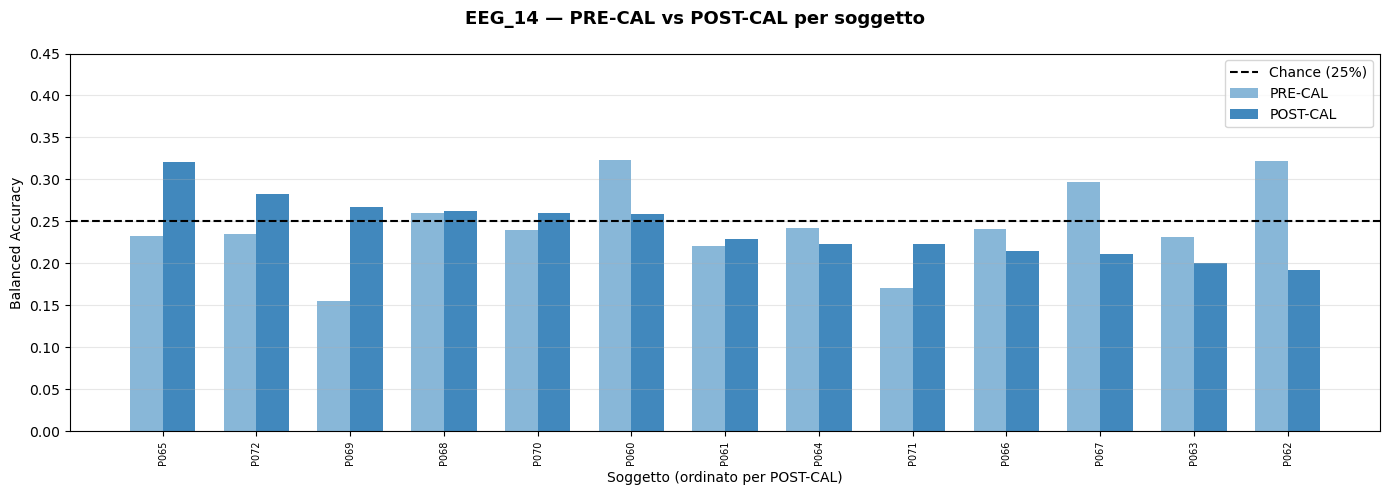

12:12:41 INFO     Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg14_pre_post_bar.png


In [8]:
if 'df_res' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    chance = 1 / N_CLASSES

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle('EEG_14 — PRE-CAL vs POST-CAL per soggetto', fontsize=13, fontweight='bold')

    x = np.arange(len(df_res))
    w = 0.35
    bars_pre  = ax.bar(x - w/2, df_res['PRE-CAL'],  w, label='PRE-CAL',  color='#7bafd4', alpha=0.9)
    bars_post = ax.bar(x + w/2, df_res['POST-CAL'], w, label='POST-CAL', color='#2C7BB6', alpha=0.9)
    ax.axhline(chance, color='black', linestyle='--', linewidth=1.5, label=f'Chance ({chance:.0%})')
    ax.set_xticks(x)
    ax.set_xticklabels(df_res['Subject'], rotation=90, fontsize=7)
    ax.set_xlabel('Soggetto (ordinato per POST-CAL)')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_ylim(0, max(df_res['POST-CAL'].max() + 0.05, 0.45))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    out = FIG_DIR / 'eeg14_pre_post_bar.png'
    plt.savefig(out, dpi=150); plt.show()
    log.info(f'Salvato: {out}')

## §8 — Confronto EEG_14 vs EEG_13b

**Delta plot**: EEG_14 (pretrain+FT) − EEG_13b (da zero) per ogni soggetto.
- Barra **verde** (Δ > 0): il pretrain ha aiutato
- Barra **rossa** (Δ < 0): fine-tuning ha peggiorato rispetto a training da zero

Tabella laterale: top-15 soggetti con maggior miglioramento.

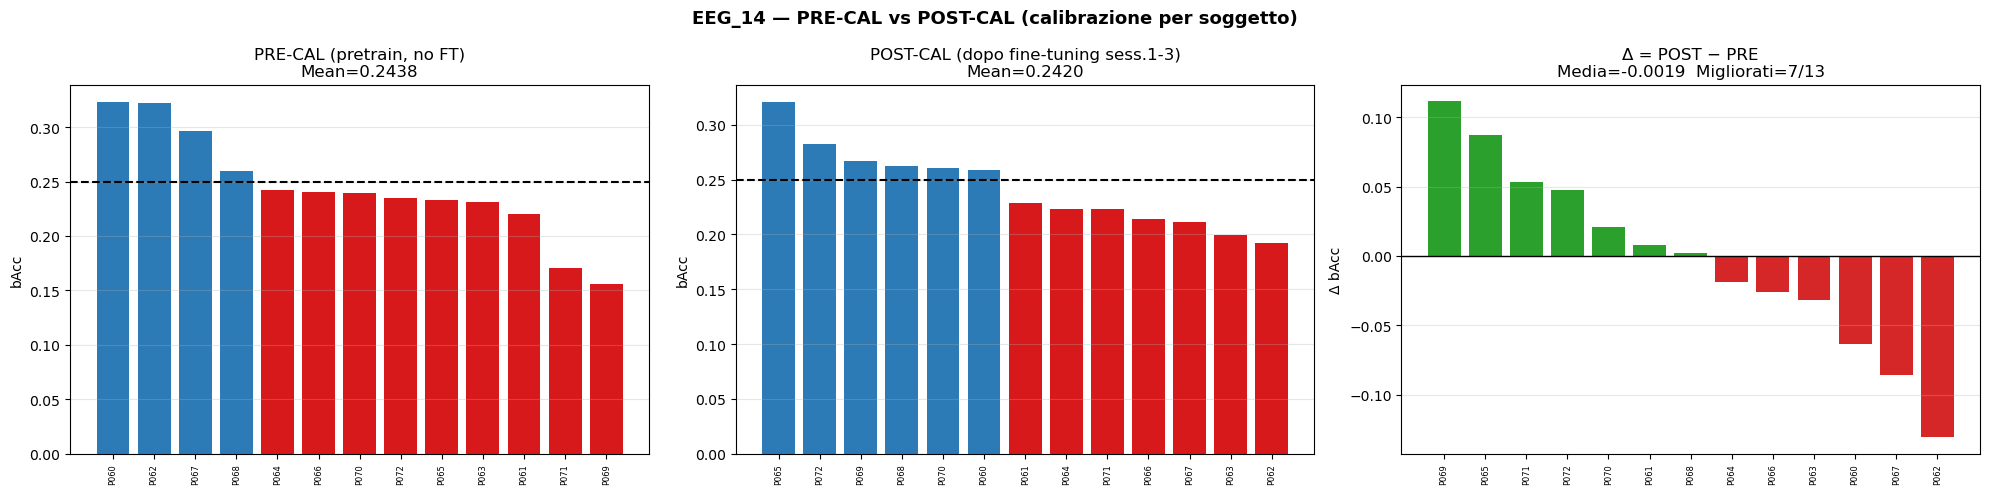

12:12:42 INFO     Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg14_pre_post_cal.png


In [9]:
if 'df_res' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    chance = 1 / N_CLASSES
    df_sorted = df_res.sort_values('Delta', ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('EEG_14 — PRE-CAL vs POST-CAL (calibrazione per soggetto)', fontsize=13, fontweight='bold')

    # Panel 1: PRE-CAL bar chart
    colors_pre = ['#2C7BB6' if v > chance else '#D7191C' for v in df_res.sort_values('PRE-CAL', ascending=False)['PRE-CAL']]
    df_pre = df_res.sort_values('PRE-CAL', ascending=False)
    axes[0].bar(range(len(df_pre)), df_pre['PRE-CAL'], color=colors_pre, width=0.8)
    axes[0].axhline(chance, color='black', linestyle='--', linewidth=1.5)
    axes[0].set_xticks(range(len(df_pre)))
    axes[0].set_xticklabels(df_pre['Subject'], rotation=90, fontsize=6)
    axes[0].set_title(f'PRE-CAL (pretrain, no FT)\nMean={df_res["PRE-CAL"].mean():.4f}')
    axes[0].set_ylabel('bAcc'); axes[0].grid(axis='y', alpha=0.3)

    # Panel 2: POST-CAL bar chart
    colors_post = ['#2C7BB6' if v > chance else '#D7191C' for v in df_res['POST-CAL']]
    axes[1].bar(range(len(df_res)), df_res['POST-CAL'], color=colors_post, width=0.8)
    axes[1].axhline(chance, color='black', linestyle='--', linewidth=1.5)
    axes[1].set_xticks(range(len(df_res)))
    axes[1].set_xticklabels(df_res['Subject'], rotation=90, fontsize=6)
    axes[1].set_title(f'POST-CAL (dopo fine-tuning sess.1-3)\nMean={df_res["POST-CAL"].mean():.4f}')
    axes[1].set_ylabel('bAcc'); axes[1].grid(axis='y', alpha=0.3)

    # Panel 3: Delta bar chart
    delta_colors = ['#2ca02c' if d > 0 else '#d62728' for d in df_sorted['Delta']]
    axes[2].bar(range(len(df_sorted)), df_sorted['Delta'], color=delta_colors, width=0.8)
    axes[2].axhline(0, color='black', linewidth=1.0)
    axes[2].set_xticks(range(len(df_sorted)))
    axes[2].set_xticklabels(df_sorted['Subject'], rotation=90, fontsize=6)
    n_imp = (df_res['Delta'] > 0).sum()
    axes[2].set_title(f'Δ = POST − PRE\nMedia={df_res["Delta"].mean():+.4f}  Migliorati={n_imp}/{len(df_res)}')
    axes[2].set_ylabel('Δ bAcc'); axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    out = FIG_DIR / 'eeg14_pre_post_cal.png'
    plt.savefig(out, dpi=150); plt.show()
    log.info(f'Salvato: {out}')

## §9 — Analisi Soggetti 'Sleeper' e Interpretazione

I soggetti per cui il pretrain aiuta di più sono potenzialmente "universally decodable" —
il loro segnale EEG ha caratteristiche che il modello generalista ha già visto nel training set.

In [10]:
if 'df_cmp' not in dir():
    print('[INFO] Esegui prima §8.')
else:
    chance = 1 / N_CLASSES

    # Soggetti che escono da chance solo con il pretrain
    unlocked = df_cmp[(df_cmp['EEG_13b'] <= chance) & (df_cmp['EEG_14'] > chance)]
    # Soggetti che regrediscono sotto chance col fine-tuning
    regressed = df_cmp[(df_cmp['EEG_13b'] > chance) & (df_cmp['EEG_14'] <= chance)]
    # Soggetti sopra chance in entrambi i modelli
    both_above = df_cmp[(df_cmp['EEG_13b'] > chance) & (df_cmp['EEG_14'] > chance)]

    print('='*60)
    print('ANALISI COMPARATIVA EEG_14 vs EEG_13b')
    print('='*60)
    print(f'\n[A] Soggetti SBLOCCATI dal pretrain (era ≤ chance, ora > chance):')
    if len(unlocked) > 0:
        print(unlocked[['Subject','EEG_13b','EEG_14','Delta']].to_string(index=False))
    else:
        print('  Nessuno.')

    print(f'\n[B] Soggetti REGREDITI dal fine-tuning (era > chance, ora ≤ chance):')
    if len(regressed) > 0:
        print(regressed[['Subject','EEG_13b','EEG_14','Delta']].to_string(index=False))
    else:
        print('  Nessuno.')

    print(f'\n[C] Sopra chance in ENTRAMBI i modelli ({len(both_above)} soggetti):')
    print(both_above[['Subject','EEG_13b','EEG_14','Delta']].sort_values('EEG_14', ascending=False).to_string(index=False))

    print(f'\n[D] Statistiche aggregate:')
    print(f'  EEG_13b — Mean: {df_cmp["EEG_13b"].mean():.4f}  Median: {df_cmp["EEG_13b"].median():.4f}  % sopra chance: {(df_cmp["EEG_13b"] > chance).mean()*100:.1f}%')
    print(f'  EEG_14  — Mean: {df_cmp["EEG_14"].mean():.4f}  Median: {df_cmp["EEG_14"].median():.4f}  % sopra chance: {(df_cmp["EEG_14"] > chance).mean()*100:.1f}%')
    print(f'  Delta   — Mean: {df_cmp["Delta"].mean():+.4f}  Median: {df_cmp["Delta"].median():+.4f}')

    print('\n[INTERPRETAZIONE]')
    if df_cmp['Delta'].mean() > 0.005:
        print('  → Il pretrain migliora sistematicamente. Le rappresentazioni S-Indep')
        print('    sono un punto di partenza più informativo di random init.')
    elif df_cmp['Delta'].mean() < -0.005:
        print('  → Il fine-tuning peggiora rispetto a training da zero.')
        print('    Probabile causa: LR_FT ancora troppo alto, oppure')
        print('    le rappresentazioni S-Indep non sono allineate con il segnale individuale.')
    else:
        print('  → Delta ≈ 0: il pretrain non porta beneficio significativo.')
        print('    Interpretazione: con ~330 trial/sogg., i pesi S-Indep vengono')
        print('    rapidamente sovrascritti → same regime del training da zero.')
        print('    Possibile soluzione: freeze encoder, fine-tune solo clf head.')

[INFO] Esegui prima §8.
